# Приклад №1

Реалізовується клас TransactionManager, методи якого об'єднують транзакції в матрицю, формують список правил-кандидатів і розраховують підтримку для кожного правила. Внутрішні функції додатково за допомогою підтримки формують списки правил і відповідно їх ранжирують.

 Як використовувати модулі на реальному датасеті?

In [7]:
# імпортування модулів
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [8]:
# завантажимо дані
dataset = pd.read_csv('/content/Basket_data.csv', header = None)

In [9]:
# виведемо датасет
dataset.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
1,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,turkey,avocado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mineral water,milk,energy bar,whole wheat rice,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
dataset.fillna(method = 'ffill',axis = 1, inplace = True)

Бачимо, що датасет у нас представляє розріджену матрицю, де у рядках у нас набір items у кожній транзакції.

In [11]:
dataset.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
1,burgers,meatballs,eggs,eggs,eggs,eggs,eggs,eggs,eggs,eggs,eggs,eggs,eggs,eggs,eggs,eggs,eggs,eggs,eggs,eggs
2,chutney,chutney,chutney,chutney,chutney,chutney,chutney,chutney,chutney,chutney,chutney,chutney,chutney,chutney,chutney,chutney,chutney,chutney,chutney,chutney
3,turkey,avocado,avocado,avocado,avocado,avocado,avocado,avocado,avocado,avocado,avocado,avocado,avocado,avocado,avocado,avocado,avocado,avocado,avocado,avocado
4,mineral water,milk,energy bar,whole wheat rice,green tea,green tea,green tea,green tea,green tea,green tea,green tea,green tea,green tea,green tea,green tea,green tea,green tea,green tea,green tea,green tea


In [12]:
# створимо з них матрицю
transactions = []
for i in range(0, 7501):
    transactions.append([str(dataset.values[i,j]) for j in range(0, 20)])

In [23]:
# імпортуємо алгоримт apriori
import sys
sys.path.append('/content/modules')
import apriori as apyori

In [24]:
%%time
# і навчимося правил. Зверніть увагу, що граничні значення ми вибираємо самі в залежності від того, /
# Наскільки "сильні" правила ми хочемо отримати
# min_support - мінімальний support для правил (dtype = float).
# min_confidence - мінімальне значення confidence для правил (dtype = float)
# min_lift - мінімальний lift (dtype = float)
# max_length - максимальна довжина itemset (згадуємо про k-itemset) (dtype = integer)

result = list(apyori.apriori(transactions, min_support = 0.003, min_confidence = 0.2, min_lift = 4, min_length = 2))

CPU times: user 328 ms, sys: 0 ns, total: 328 ms
Wall time: 330 ms


**Візуалізуємо вихід**

In [25]:
import shutil, os

In [26]:
try:
    from StringIO import StringIO
except ImportError:
    from io import StringIO

In [27]:
import json

In [28]:
output = []
for RelationRecord in result:
    o = StringIO()
    apyori.dump_as_json(RelationRecord, o)
    output.append(json.loads(o.getvalue()))
data_df = pd.DataFrame(output)

In [29]:
# подивимося на підсумки
pd.set_option('display.max_colwidth', -1)

from IPython.display import display, HTML

display(HTML(data_df.to_html()))

<ipython-input-29-a787a6126ad4>:2: FutureWarning: Passing a negative integer is deprecated in version 1.0 and will not be supported in future version. Instead, use None to not limit the column width.
  pd.set_option('display.max_colwidth', -1)


,items,support,ordered_statistics
0,"[chicken, light cream]",0.004533,"[{'items_base': ['light cream'], 'items_add': ['chicken'], 'confidence': 0.29059829059829057, 'lift': 4.84395061728395}]"
1,"[escalope, pasta]",0.005866,"[{'items_base': ['pasta'], 'items_add': ['escalope'], 'confidence': 0.3728813559322034, 'lift': 4.700811850163794}]"
2,"[fromage blanc, honey]",0.003333,"[{'items_base': ['fromage blanc'], 'items_add': ['honey'], 'confidence': 0.2450980392156863, 'lift': 5.164270764485569}]"
3,"[olive oil, whole wheat pasta]",0.007999,"[{'items_base': ['whole wheat pasta'], 'items_add': ['olive oil'], 'confidence': 0.2714932126696833, 'lift': 4.122410097642296}]"
4,"[pasta, shrimp]",0.005066,"[{'items_base': ['pasta'], 'items_add': ['shrimp'], 'confidence': 0.3220338983050847, 'lift': 4.506672147735896}]"
5,"[cake, frozen vegetables, tomatoes]",0.003066,"[{'items_base': ['cake', 'frozen vegetables'], 'items_add': ['tomatoes'], 'confidence': 0.2987012987012987, 'lift': 4.367560314928736}]"
6,"[cereals, ground beef, spaghetti]",0.003066,"[{'items_base': ['cereals', 'spaghetti'], 'items_add': ['ground beef'], 'confidence': 0.45999999999999996, 'lift': 4.681763907734057}]"
7,"[chocolate, ground beef, herb & pepper]",0.003999,"[{'items_base': ['chocolate', 'herb & pepper'], 'items_add': ['ground beef'], 'confidence': 0.4411764705882354, 'lift': 4.4901827759597746}]"
8,"[eggs, ground beef, herb & pepper]",0.004133,"[{'items_base': ['eggs', 'ground beef'], 'items_add': ['herb & pepper'], 'confidence': 0.2066666666666667, 'lift': 4.178454627133872}]"
9,"[french fries, ground beef, herb & pepper]",0.003200,"[{'items_base': ['french fries', 'ground beef'], 'items_add': ['herb & pepper'], 'confidence': 0.23076923076923078, 'lift': 4.665768194070081}, {'items_base': ['french fries', 'herb & pepper'], 'items_add': ['ground beef'], 'confidence': 0.46153846153846156, 'lift': 4.697421981004071}]"


***Усього ми бачимо:***<br>


1. Пари items
2. items_base – перший елемент пари
3. items_add – другий (доданий алгоритмом) елемент пари
4. confidence – значення confidence для пари
5. lift – значення lift для пари
6. support - начення support для пари. За бажанням, за ним можна відсортувати


Результати логічні: ескалоп та макарони, ескалоп та вершково-грибний соус, курка та нежирна сметана, м'який сир та мед тощо. - все це цілком логічні і, головне, смачні поєднання:)

Відображення **правила та складові їх ознаки у вигляді графа**, розмір вузлів якого пропорційний рівню підтримки кожного наявного правила.

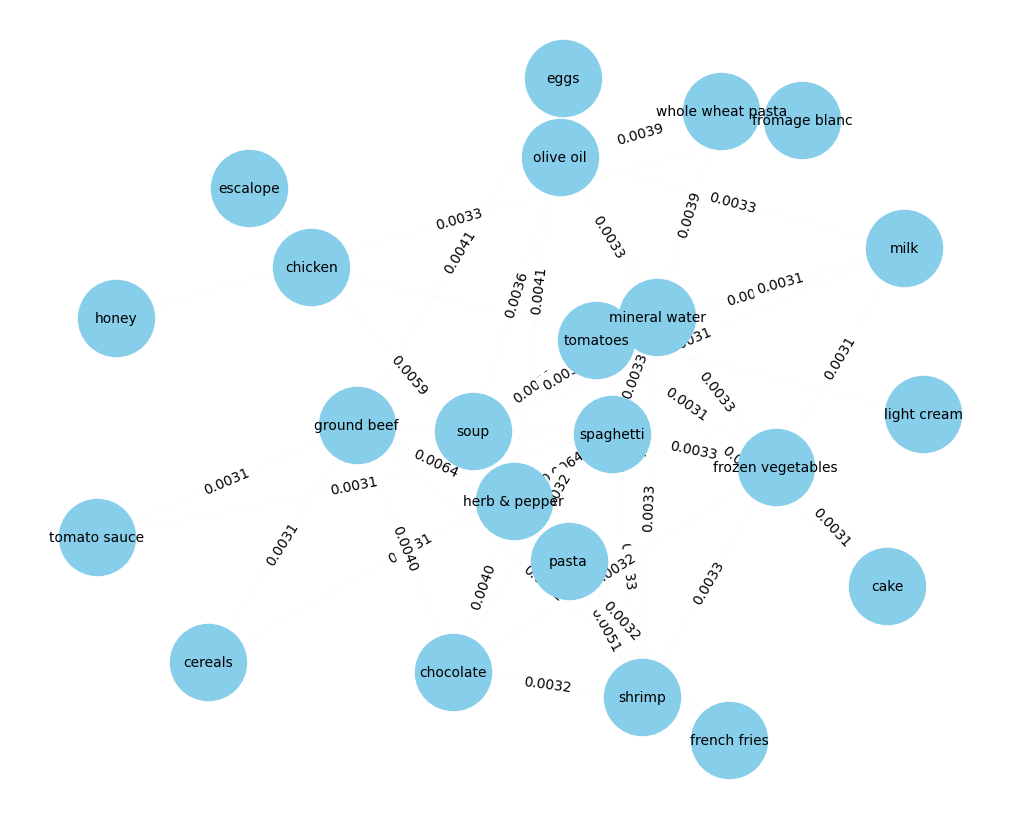

In [30]:
import networkx as nx
import matplotlib.pyplot as plt

# Створення графа
G = nx.Graph()

# Додавання ребер та визначення їх ваг
for _, row in data_df.iterrows():
    items = row['items']
    support = row['support']
    for i in range(len(items)-1):
        for j in range(i+1, len(items)):
            G.add_edge(items[i], items[j], weight=support)

# Визначення позицій вершин графа
pos = nx.spring_layout(G)

# Виведення графа
plt.figure(figsize=(10, 8))
nx.draw(G, pos, with_labels=True, font_size=10, font_color='black', node_size=3000, node_color='skyblue', edge_color='gray', width=[d['weight']*5 for (u, v, d) in G.edges(data=True)])
nx.draw_networkx_edge_labels(G, pos, edge_labels={(u, v): f"{d['weight']:.4f}" for (u, v, d) in G.edges(data=True)})
plt.show()

 **Створення піч діаграми:**

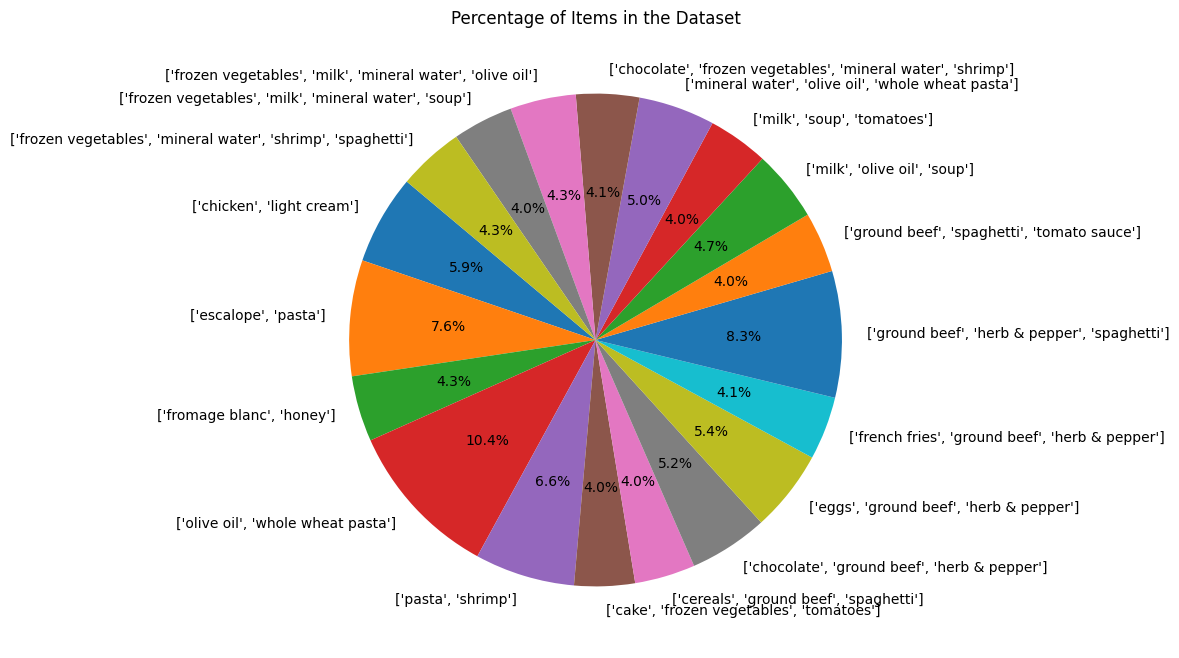

In [31]:
df = data_df
# Обчислення відсотків
total_items = sum(data_df['support'])
data_df['percentage'] = (data_df['support'] / total_items) * 100

# Створення діаграми піч
plt.figure(figsize=(10, 8))
plt.pie(data_df['percentage'], labels=df['items'], autopct='%1.1f%%', startangle=140)
plt.title('Percentage of Items in the Dataset')
plt.show()

**Створення стовпчикової діаграми порівняння**

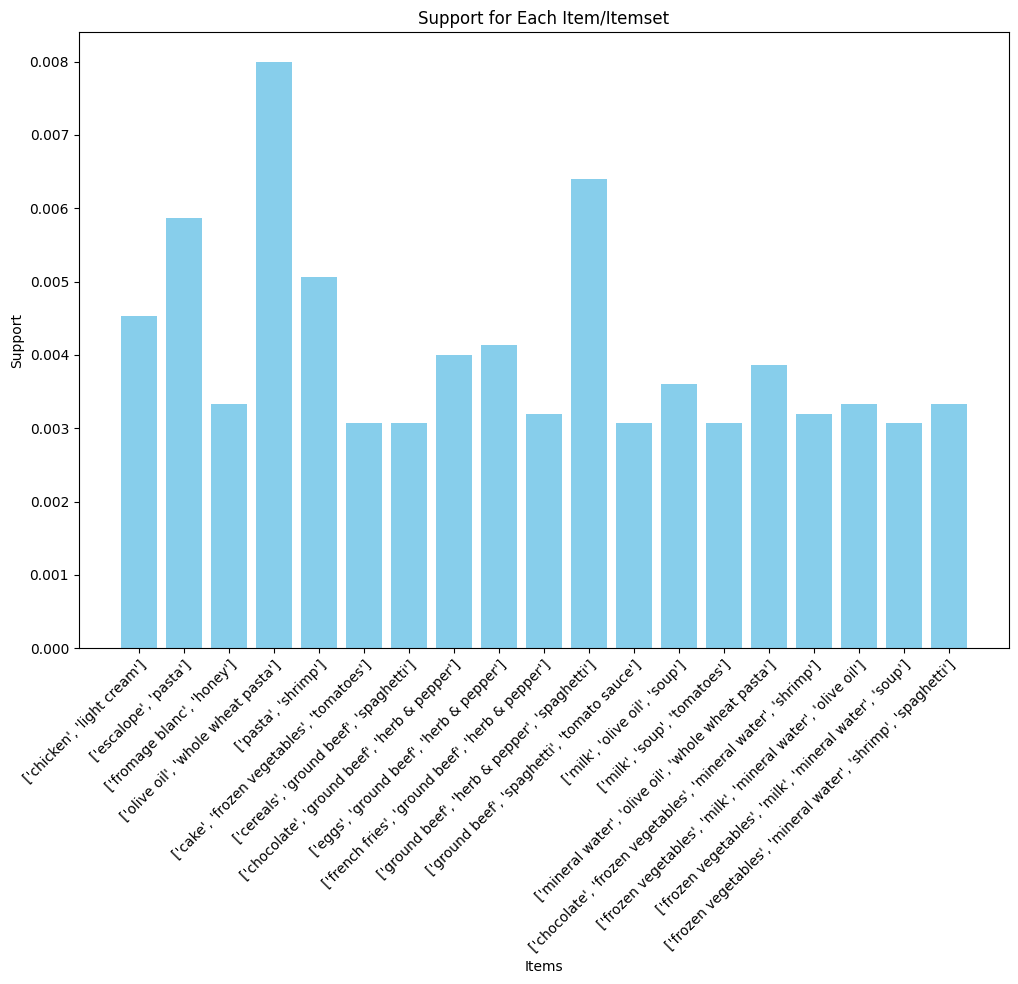

In [32]:
plt.figure(figsize=(12, 8))
plt.bar(df['items'].apply(str), df['support'], color='skyblue')
plt.xlabel('Items')
plt.ylabel('Support')
plt.title('Support for Each Item/Itemset')
plt.xticks(rotation=45, ha='right', rotation_mode='anchor')
plt.show()